--- Configuring Environment ---
Using device: cuda
******************************
Script configured for LOADING models and Grad-CAM explainability.
******************************
--- Defining Transforms ---
--- Defining Model Configurations ---


C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\timm\models\_factory.py:117: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Adjusting final layers...
Model heads adjusted.

--- Loading Pre-Trained Model Weights ---
  Loading ResNet18 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_ResNet18.pth...
  Successfully loaded ResNet18.
  Loading EfficientNet from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_EfficientNet.pth...


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_28540\3310993736.py:313: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(load_path, map_location=device)

  Successfully loaded EfficientNet.
  Loading DenseNet121 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_DenseNet121.pth...
  Successfully loaded DenseNet121.
  Loading Xception from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_Xception.pth...
  Successfully loaded Xception.
  Loading MobileNetV2 from C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models\best_model_MobileNetV2.pth...
  Successfully loaded MobileNetV2.

Successfully loaded 5 models: ['ResNet18', 'EfficientNet', 'DenseNet121', 'Xception', 'MobileNetV2']

--- Preparing Data for Evaluation ---
Train subset: 1174 samples. Test subset: 253 samples.

--- Generating Grad-CAM Explanations for a Sample Image ---
Explaining image index 52 (True Class: non_recurrence)


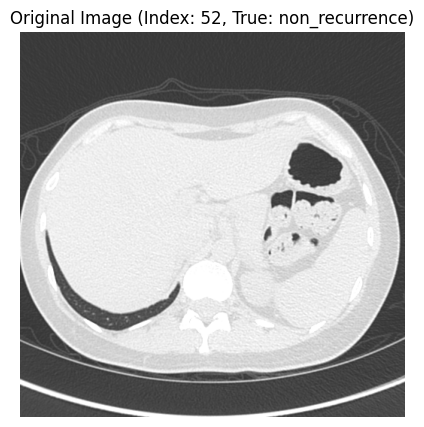


--- Explanations for ResNet18 ---
  Model Prediction: non_recurrence (Confidence: 0.9999)
  Generating Grad-CAM...
  Finding target layer for ResNet18...
    Targeting ResNet layer: Conv2d
  Grad-CAM generated.
  Grad-CAM visualization saved to ./Lung_Cancer_Outputs_GradCAM\explanations\explain_gradcam_ResNet18_sample_52.png


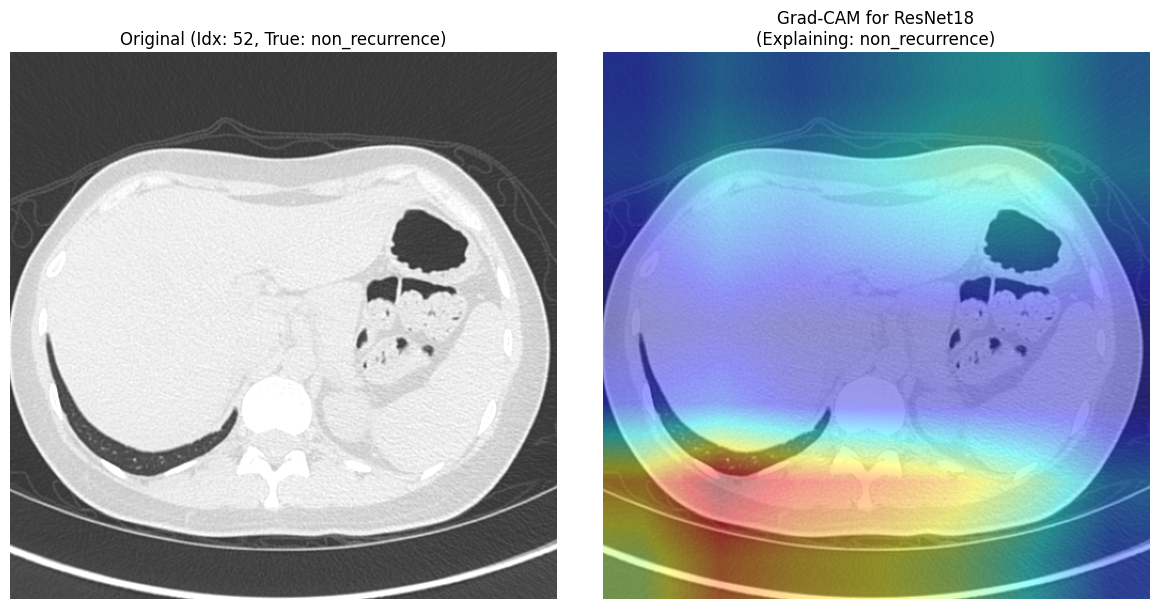

------------------------------

--- Explanations for EfficientNet ---
  Model Prediction: non_recurrence (Confidence: 1.0000)
  Generating Grad-CAM...
  Finding target layer for EfficientNet...
    Targeting EfficientNet layer: Last nn.Conv2d in features.
  Grad-CAM generated.
  Grad-CAM visualization saved to ./Lung_Cancer_Outputs_GradCAM\explanations\explain_gradcam_EfficientNet_sample_52.png


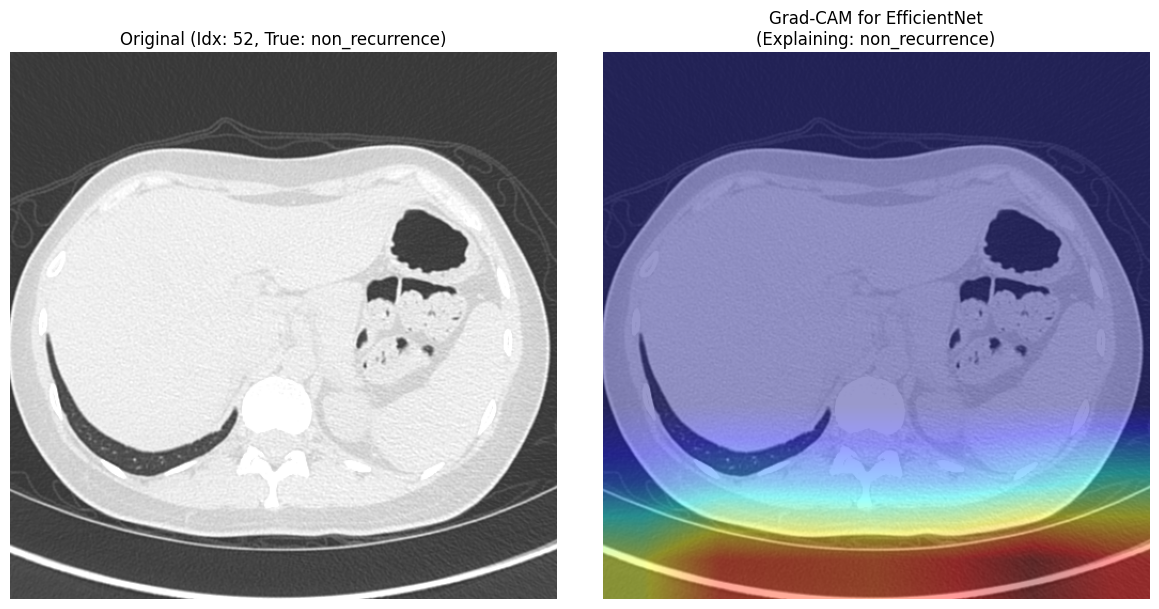

------------------------------

--- Explanations for DenseNet121 ---
  Model Prediction: non_recurrence (Confidence: 1.0000)
  Generating Grad-CAM...
  Finding target layer for DenseNet121...
    Targeting DenseNet layer: Last nn.Conv2d in features.
  Grad-CAM generated.
  Grad-CAM visualization saved to ./Lung_Cancer_Outputs_GradCAM\explanations\explain_gradcam_DenseNet121_sample_52.png


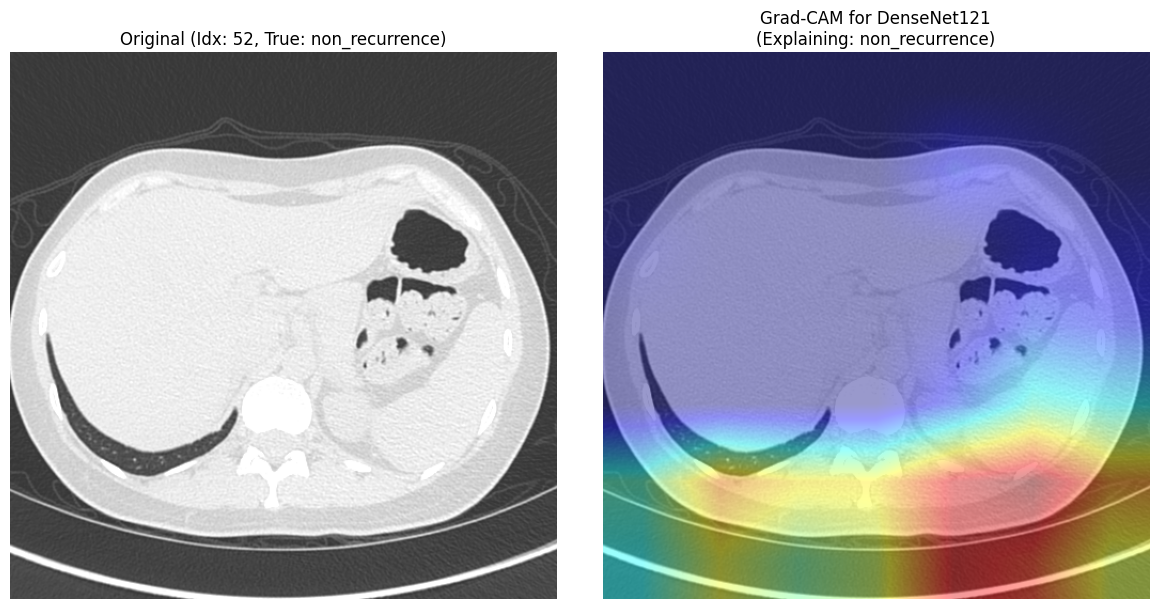

------------------------------

--- Explanations for Xception ---
  Model Prediction: non_recurrence (Confidence: 0.9997)
  Generating Grad-CAM...
  Finding target layer for Xception...
    Targeting Xception layer: Last nn.Conv2d in block11.rep.
  Grad-CAM generated.
  Grad-CAM visualization saved to ./Lung_Cancer_Outputs_GradCAM\explanations\explain_gradcam_Xception_sample_52.png


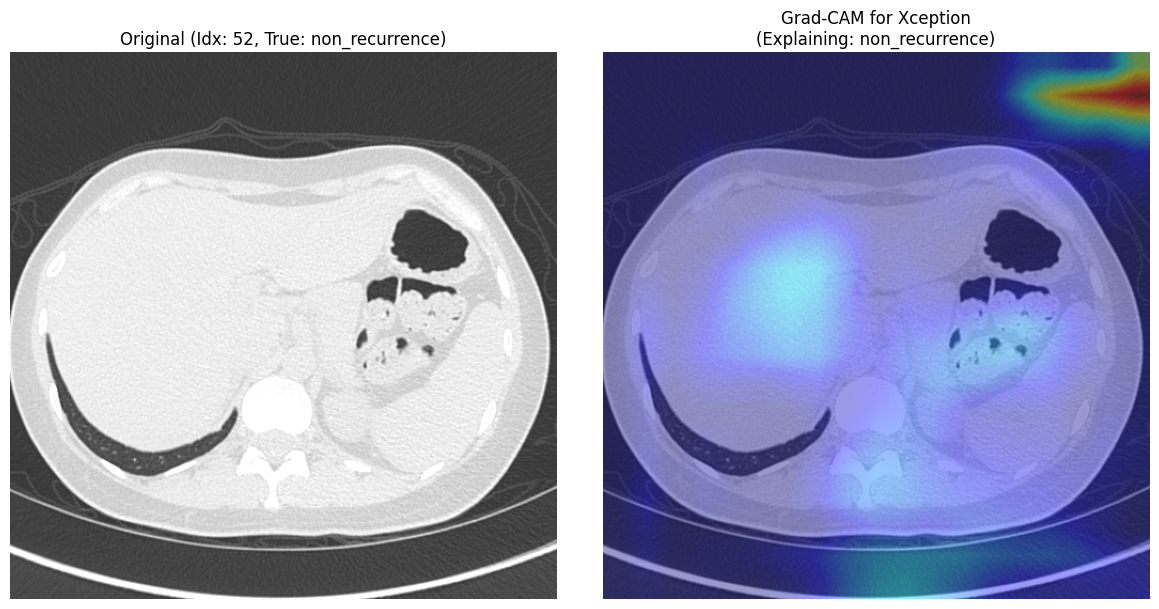

------------------------------

--- Explanations for MobileNetV2 ---
  Model Prediction: non_recurrence (Confidence: 1.0000)
  Generating Grad-CAM...
  Finding target layer for MobileNetV2...
    Targeting MobileNetV2 layer: Last nn.Conv2d in features.
  Grad-CAM generated.
  Grad-CAM visualization saved to ./Lung_Cancer_Outputs_GradCAM\explanations\explain_gradcam_MobileNetV2_sample_52.png


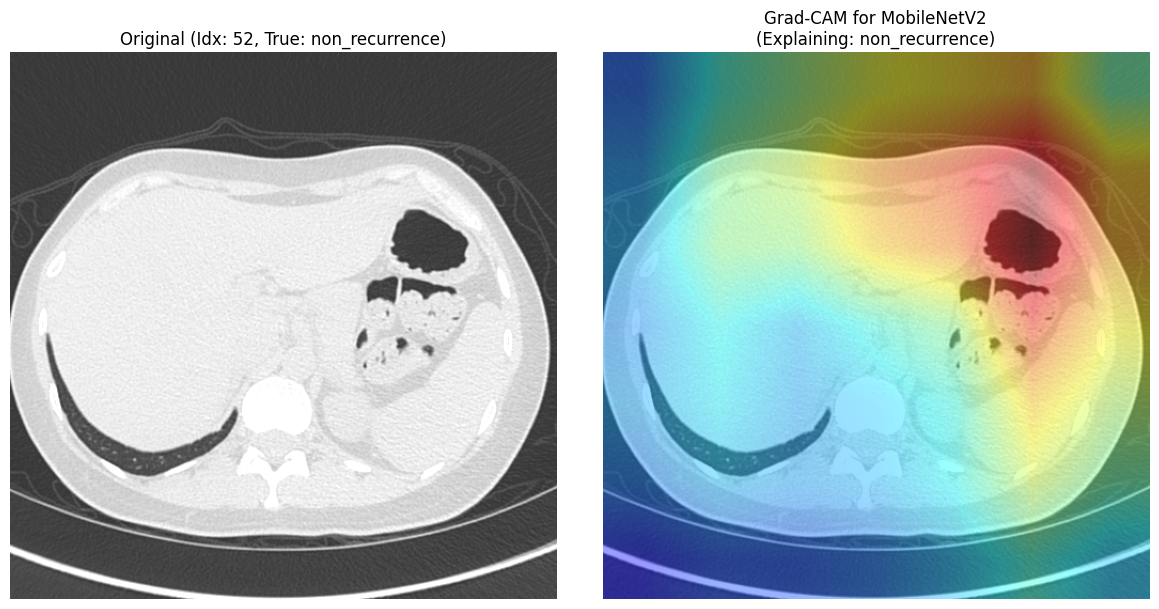

------------------------------

--- Calculating Majority Vote for the Sample ---
  Vote from ResNet18: non_recurrence
  Vote from EfficientNet: non_recurrence
  Vote from DenseNet121: non_recurrence
  Vote from Xception: non_recurrence
  Vote from MobileNetV2: non_recurrence

Majority Vote Result: non_recurrence (Votes: 5/5)

--- Explanation Sample Prediction Summary ---
          Model      True Class Predicted Class  Confidence
0      ResNet18  non_recurrence  non_recurrence    0.999925
1  EfficientNet  non_recurrence  non_recurrence    0.999998
2   DenseNet121  non_recurrence  non_recurrence    0.999957
3      Xception  non_recurrence  non_recurrence    0.999659
4   MobileNetV2  non_recurrence  non_recurrence    1.000000
Explanation summary saved.


In [11]:
# Lung Cancer Recurrence Prediction: Loading Models and Grad-CAM Explainability

# --- 1. Imports ---
import os
import random
import time
import copy
import warnings # To suppress warnings if needed

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset, Dataset
from timm import create_model # For Xception

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
# Removed: from sklearn.manifold import TSNE (unless needed elsewhere)

import pydicom
from PIL import Image
import cv2 # For Grad-CAM overlay
# Removed: import shap

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Use tqdm.notebook for Jupyter, plain tqdm otherwise
import numpy as np
import pandas as pd
import seaborn as sns


# --- 2. Configuration ---
print("--- Configuring Environment ---")
# !!! ADJUST PATHS AND PARAMETERS AS NEEDED !!!
DATASET_PATH = r"C:\Users\THILAK R\OneDrive\Desktop\chest_cancer"
MODEL_SAVE_DIR = r"C:\Users\THILAK R\OneDrive\Desktop\Reccurence Lung Cancer\Models"
# Define save locations for outputs of this script
OUTPUT_DIR = "./Lung_Cancer_Outputs_GradCAM" # Changed output dir name
# Removed: RESULTS_SAVE_PATH, ENSEMBLE_RESULTS_SAVE_PATH (assuming not needed now)
PLOTS_SAVE_DIR = os.path.join(OUTPUT_DIR, "plots")
EXPLAIN_SAVE_DIR = os.path.join(OUTPUT_DIR, "explanations")

# Training/Evaluation Params (used for loading/evaluation setup)
BATCH_SIZE = 32
SPLIT_RATIO = (0.7, 0.15, 0.15) # Must match the split used during training for consistency
RANDOM_STATE = 42

# CT Windowing
WINDOW_CENTER = -600
WINDOW_WIDTH = 1500

# Removed: ENSEMBLE_WEIGHTS
# Removed: SHAP_BACKGROUND_SAMPLES

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True) # Ensure model load dir exists
os.makedirs(PLOTS_SAVE_DIR, exist_ok=True)
os.makedirs(EXPLAIN_SAVE_DIR, exist_ok=True)
print("*"*30 + "\nScript configured for LOADING models and Grad-CAM explainability.\n" + "*"*30)


# --- 3. Helper Functions and Classes ---

# -- DICOM Preprocessing --
def apply_window(img_array, center, width):
    min_val=center-width//2; max_val=center+width//2
    img_array=np.clip(img_array,min_val,max_val)
    if max_val>min_val: img_array=(img_array-min_val)/(max_val-min_val)
    else: img_array=np.zeros_like(img_array)
    return img_array

# -- Custom Datasets --
class DicomImageFolderDataset(Dataset):
    def __init__(self, root_dir, window_center=None, window_width=None, transform=None):
        self.root_dir = root_dir; self.window_center = window_center; self.window_width = window_width; self.transform = transform
        self.classes = sorted([d.name for d in os.scandir(root_dir) if d.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}; self.samples = self._find_samples()
        self.targets = [s[1] for s in self.samples]
        if not self.samples: raise FileNotFoundError(f"Found no '.dcm' files in subfolders of {root_dir}")
    def _find_samples(self):
        samples = [];
        for class_name in self.classes:
            class_idx = self.class_to_idx[class_name]; class_dir = os.path.join(self.root_dir, class_name)
            if not os.path.isdir(class_dir): continue
            for fname in sorted(os.listdir(class_dir)):
                 if fname.lower().endswith('.dcm'): samples.append((os.path.join(class_dir, fname), class_idx))
        return samples
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        try:
            ds = pydicom.dcmread(filepath, stop_before_pixels=False); img_array = ds.pixel_array.astype(np.float32)
            if not hasattr(ds, 'PixelData') or ds.PixelData is None: raise ValueError("No PixelData")
            slope=float(ds.RescaleSlope) if 'RescaleSlope' in ds else 1.0; intercept=float(ds.RescaleIntercept) if 'RescaleIntercept' in ds else 0.0
            if slope!=1.0 or intercept!=0.0: img_array=img_array*slope+intercept
            if self.window_center is not None and self.window_width is not None: img_array_windowed = apply_window(img_array, self.window_center, self.window_width)
            else: min_val,max_val=np.min(img_array),np.max(img_array); img_array_windowed = (img_array-min_val)/(max_val-min_val) if max_val>min_val else np.zeros_like(img_array)
            if np.isnan(img_array_windowed).any() or np.isinf(img_array_windowed).any(): raise ValueError("NaN/Inf in array")
            img_array_clamped=np.clip(img_array_windowed,0.0,1.0); img_array_uint8=(img_array_clamped*255).astype(np.uint8); img_pil=Image.fromarray(img_array_uint8).convert('RGB')
            if self.transform: return self.transform(img_pil), label
            else: return img_pil, label # Return PIL for BaseImageDataset
        except Exception as e: print(f"ERROR loading {filepath}: {e}. Returning placeholder."); placeholder_img=Image.new('RGB',(224,224),color='grey'); return (self.transform(placeholder_img), label) if self.transform else (placeholder_img, label)

class TransformedDataset(Dataset):
    def __init__(self, subset, transform): self.subset = subset; self.transform = transform
    def __getitem__(self, index):
        # Assumes subset's __getitem__ returns (PIL Image, label)
        x_pil, y = self.subset[index]
        # Apply the torchvision transform
        if self.transform: x_tensor = self.transform(x_pil)
        else: x_tensor = transforms.ToTensor()(x_pil) # Fallback
        return x_tensor, y
    def __len__(self): return len(self.subset)

# Removed: BaseImageDataset (no longer needed as we use TransformedDataset)
# Removed: collate_pil (no longer needed)

# -- Plotting Helpers --
# Removed: plot_training_history (not relevant in loading mode)
# Removed: plot_confusion_matrix, plot_roc_curve (unless you add back individual/ensemble evaluation)

# -- Grad-CAM Helpers --
features_blobs = []
backward_blobs = []
def hook_feature(module, input, output): features_blobs.append(output.detach().clone())
def hook_backward(module, grad_in, grad_out): backward_blobs.append(grad_out[0].detach().clone())
def find_target_layer(model, model_name):
    """Try to find a suitable last convolutional layer for Grad-CAM."""
    # Import necessary types within the function if needed for clarity
    from torchvision.ops import Conv2dNormActivation
    # from torchvision.models.efficientnet import MBConv # May not be needed if checking isinstance directly

    print(f"  Finding target layer for {model_name}...")

    if isinstance(model, models.ResNet):
        target = model.layer4[-1].conv3 if hasattr(model.layer4[-1], 'conv3') else model.layer4[-1].conv2
        print(f"    Targeting ResNet layer: {type(target).__name__}")
        return target
    elif isinstance(model, models.DenseNet):
        # Target the final Conv layer within the entire features block, just before pooling
        target = model.features.conv5 if hasattr(model.features, 'conv5') else model.features[-1] # Often the last conv in the last dense layer or transition
        # Refine: Look backwards within features for the last Conv2d
        for layer in reversed(list(model.features.modules())):
             if isinstance(layer, nn.Conv2d):
                  print(f"    Targeting DenseNet layer: Last nn.Conv2d in features.")
                  return layer
        print(f"Warning: Fallback DenseNet target: {type(target).__name__}") # Fallback if no conv found iterating
        return target # Return norm5 or last layer as fallback
    elif isinstance(model, models.EfficientNet) or isinstance(model, models.MobileNetV2):
         # Iterate backwards through features to find the last Conv2d
         if hasattr(model, 'features'):
              for layer in reversed(list(model.features.modules())):
                    if isinstance(layer, nn.Conv2d):
                         print(f"    Targeting {model_name} layer: Last nn.Conv2d in features.")
                         return layer
         # Fallback if no Conv2d found in features (less likely)
         print(f"Warning: No Conv2d found in {model_name}.features. Trying fallback.")
         return model.features[-1] # Default fallback

    elif model_name == "Xception":
        # Target the last Conv2d within the final block (block11 for legacy_xception)
        if hasattr(model, 'block11') and hasattr(model.block11, 'rep'):
            # Iterate backwards through the 'rep' sequential in the last block
             for layer in reversed(list(model.block11.rep.modules())):
                  if isinstance(layer, nn.Conv2d):
                      print(f"    Targeting Xception layer: Last nn.Conv2d in block11.rep.")
                      return layer
        # Fallback if structure differs
        print(f"Warning: Could not find conv in Xception block11. Using act4 as fallback.")
        if hasattr(model, 'act4'): return model.act4 # Fallback to activation if conv not found
        else: print("Error: Cannot find suitable Xception layer."); return None

    else: # General fallback if model type is unknown
        for layer in reversed(list(model.modules())):
            if isinstance(layer, nn.Conv2d):
                print(f"    Targeting {model_name} layer: Fallback last nn.Conv2d.")
                return layer

    print(f"Warning: Could not find any Conv2d target layer for {model_name}. Grad-CAM may fail.")
    return None
def generate_grad_cam(model, input_tensor, target_layer, target_class_index):
    global features_blobs, backward_blobs; features_blobs = []; backward_blobs = []
    handle_forward = None; handle_backward = None; heatmap_np = None; calculated_target_index = target_class_index
    try:
        handle_forward = target_layer.register_forward_hook(hook_feature)
        handle_backward = target_layer.register_full_backward_hook(hook_backward)
        outputs = model(input_tensor);
        if target_class_index is None: calculated_target_index = torch.argmax(outputs, dim=1).item()
        else: calculated_target_index = target_class_index
        one_hot_output = torch.zeros_like(outputs); one_hot_output[0][calculated_target_index] = 1
        model.zero_grad(); outputs.backward(gradient=one_hot_output, retain_graph=True)
        if not backward_blobs or not features_blobs: print("Error: Hooks failed."); return None, calculated_target_index
        gradients = backward_blobs[0].clone(); activations = features_blobs[0].clone()
        pooled_gradients = torch.mean(gradients, dim=[2, 3])
        weighted_activations = activations.clone()
        for i in range(activations.shape[1]): weighted_activations[:, i, :, :] *= pooled_gradients[:, i].unsqueeze(-1).unsqueeze(-1)
        heatmap = torch.mean(weighted_activations, dim=1).squeeze(); heatmap = F.relu(heatmap)
        if torch.max(heatmap) > 0: heatmap /= torch.max(heatmap)
        heatmap_np = heatmap.cpu().numpy()
    except Exception as e: print(f"Error during Grad-CAM calculation: {e}")
    finally:
        if handle_forward: handle_forward.remove()
        if handle_backward: handle_backward.remove()
        features_blobs = []; backward_blobs = []
    return heatmap_np, calculated_target_index
def show_cam_on_image(img_np, heatmap):
    if img_np.max() <= 1.0: img_np = (img_np * 255).astype(np.uint8)
    else: img_np = img_np.astype(np.uint8)
    if len(img_np.shape) == 2 or img_np.shape[2] == 1: img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)
    heatmap_resized = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img_np, 0.6, heatmap_colored, 0.4, 0)
    return cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

# -- Visualization Function for Grad-CAM --
def visualize_gradcam_results(original_pil_image, grad_cam_heatmap,
                             model_name, pred_class_name, true_class_name,
                             save_dir, random_idx):
    """Visualize Original and Grad-CAM explanations side-by-side."""
    grad_cam_plot_available = grad_cam_heatmap is not None

    fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # 1 row, 2 columns

    # Original Image
    axes[0].imshow(original_pil_image)
    axes[0].set_title(f"Original (Idx: {random_idx}, True: {true_class_name})")
    axes[0].axis('off')

    # Grad-CAM Visualization
    if grad_cam_plot_available:
        try:
            display_img_np = np.array(original_pil_image).astype(np.float32) / 255.0
            grad_cam_overlay = show_cam_on_image(display_img_np, grad_cam_heatmap)
            axes[1].imshow(grad_cam_overlay)
            axes[1].set_title(f"Grad-CAM for {model_name}\n(Explaining: {pred_class_name})")
        except Exception as gc_viz_e:
            print(f"  Error visualizing Grad-CAM: {gc_viz_e}")
            axes[1].text(0.5, 0.5, "Grad-CAM Viz Error", ha='center', va='center', color='red')
            axes[1].set_title(f"Grad-CAM for {model_name}")
    else:
         axes[1].text(0.5, 0.5, "Grad-CAM Failed", ha='center', va='center', color='red')
         axes[1].set_title(f"Grad-CAM for {model_name}")
    axes[1].axis('off')

    plt.tight_layout()
    main_save_path = os.path.join(save_dir, f"explain_gradcam_{model_name}_sample_{random_idx}.png")
    plt.savefig(main_save_path)
    print(f"  Grad-CAM visualization saved to {main_save_path}")
    plt.show() # Display the plot


# --- 4. Define Transforms ---
print("--- Defining Transforms ---")
base_input_size = (224, 224)
xception_input_size = (299, 299)
data_transforms = {
    "base": transforms.Compose([
        transforms.Resize(base_input_size), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    "Xception": transforms.Compose([
        transforms.Resize(xception_input_size), transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
}


# --- 5. Define Model Structures & Configuration ---
print("--- Defining Model Configurations ---")
num_classes = 2
models_definition = {
    "ResNet18": {"model": models.resnet18(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    "EfficientNet": {"model": models.efficientnet_b0(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    "DenseNet121": {"model": models.densenet121(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
    "Xception": {"model": create_model("xception", pretrained=False, num_classes=1000), "input_size": (299, 299), "transform": data_transforms["Xception"]},
    "MobileNetV2": {"model": models.mobilenet_v2(weights=None), "input_size": (224, 224), "transform": data_transforms["base"]},
}
print("Adjusting final layers...")
# (Keep the layer adjustment loop as before)
for name, config in models_definition.items():
    model = config["model"]; adjusted = False
    if name == "Xception":
         if hasattr(model, 'fc'): model.fc = nn.Linear(model.fc.in_features, num_classes); adjusted = True
    elif hasattr(model, 'fc'): # ResNet
        if model.fc.out_features != num_classes: model.fc = nn.Linear(model.fc.in_features, num_classes); adjusted = True
    elif hasattr(model, 'classifier'): # EfficientNet, DenseNet, MobileNetV2
        if isinstance(model.classifier, nn.Sequential):
             if len(model.classifier) > 0 and isinstance(model.classifier[-1], nn.Linear):
                  if model.classifier[-1].out_features != num_classes: model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes); adjusted = True
        elif isinstance(model.classifier, nn.Linear):
             if hasattr(model.classifier, 'out_features') and model.classifier.out_features != num_classes: model.classifier = nn.Linear(model.classifier.in_features, num_classes); adjusted = True
             elif not hasattr(model.classifier, 'out_features'):
                 try: # Try accessing last element assuming sequential
                     if isinstance(model.classifier[-1], nn.Linear) and model.classifier[-1].out_features != num_classes: model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes); adjusted = True
                 except TypeError: pass # Handle cases where classifier isn't sequential/subscriptable
    #if adjusted: print(f"  Adjusted head for {name}")
print("Model heads adjusted.")


# --- 6. Load Trained Model Weights ---
print("\n--- Loading Pre-Trained Model Weights ---")
trained_models = {}
for model_name, config in models_definition.items():
    model = config["model"]; load_path = os.path.join(MODEL_SAVE_DIR, f"best_model_{model_name}.pth")
    if os.path.exists(load_path):
        print(f"  Loading {model_name} from {load_path}...")
        try:
            state_dict = torch.load(load_path, map_location=device); model.load_state_dict(state_dict); model.to(device); model.eval()
            trained_models[model_name] = model; print(f"  Successfully loaded {model_name}.")
        except Exception as e: print(f"  ERROR loading {model_name}: {type(e).__name__} - {e}")
    else: print(f"  Warning: Weights not found for {model_name}. Skipping.")
if not trained_models: raise RuntimeError("No models loaded.")
print(f"\nSuccessfully loaded {len(trained_models)} models: {list(trained_models.keys())}")


# --- 7. Data Loading for Evaluation ---
print("\n--- Preparing Data for Evaluation ---")
full_dataset = None; train_subset = None; test_subset = None; class_names = ['unknown_0', 'unknown_1'] # Defaults
try:
    full_dataset = DicomImageFolderDataset(DATASET_PATH, window_center=WINDOW_CENTER, window_width=WINDOW_WIDTH, transform=None)
    class_names = full_dataset.classes; num_classes = len(class_names)
    if num_classes != 2: print(f"Warning: Found {num_classes} classes. Code assumes binary.")
    n_total=len(full_dataset); n_train=int(n_total*SPLIT_RATIO[0]); n_val=int(n_total*SPLIT_RATIO[1]); n_test=n_total-n_train-n_val
    # Use the same random state used during training
    train_indices, val_test_indices = train_test_split(list(range(n_total)), train_size=n_train, stratify=full_dataset.targets, random_state=RANDOM_STATE)
    val_test_labels = [full_dataset.targets[i] for i in val_test_indices]
    val_proportion = n_val / (n_val + n_test) if (n_val + n_test) > 0 else 0
    if len(set(val_test_labels)) < 2 or val_proportion <= 0 or val_proportion >= 1 or n_val == 0 or n_test == 0 :
         print("Splitting val/test non-stratified.")
         val_indices, test_indices = train_test_split(val_test_indices, train_size=n_val, random_state=RANDOM_STATE) # Fallback to train_size if test_size is needed
         if n_test <= 0 and n_val > 0: test_indices = [] # Ensure test is empty if n_test=0
         elif n_val <= 0 and n_test > 0: val_indices = [] # Ensure val is empty if n_val=0

    else:
         val_indices, test_indices = train_test_split(val_test_indices, test_size=n_test, stratify=val_test_labels, random_state=RANDOM_STATE)

    train_subset = Subset(full_dataset, train_indices); test_subset = Subset(full_dataset, test_indices)
    print(f"Train subset: {len(train_subset)} samples. Test subset: {len(test_subset)} samples.")
except Exception as e: print(f"FATAL: Error setting up dataset/subsets: {e}")


# --- 8. Individual Model Evaluation (Optional) ---
# print("\n--- Individual Model Evaluation ---")
# ... (Code for individual evaluation if needed) ...


# --- 9. Ensemble Evaluation (Optional) ---
# print("\n--- Ensemble Evaluation ---")
# ... (Code for ensemble evaluation if needed, requires evaluate_ensemble function) ...


# --- 10. Explainability (Grad-CAM Only) ---
print("\n--- Generating Grad-CAM Explanations for a Sample Image ---")
# Initialize variables outside the main conditional block
sample_pil_image = None
true_class_name = "N/A"
random_idx = -1
explanation_results_list = [] # Initialize list to store results

if test_subset and len(test_subset) > 0 and trained_models:
    random_idx = random.randrange(len(test_subset))
    try:
        sample_pil_image, sample_label_idx = test_subset[random_idx] # Get PIL image
        true_class_name = class_names[sample_label_idx]
        print(f"Explaining image index {random_idx} (True Class: {true_class_name})")
        # Display original image once
        plt.figure(figsize=(5, 5)); plt.imshow(sample_pil_image); plt.title(f"Original Image (Index: {random_idx}, True: {true_class_name})"); plt.axis('off'); plt.show()

    except Exception as e:
        print(f"Error getting sample image/label at index {random_idx}: {e}")
        test_subset = None # Mark as unusable

if test_subset and len(test_subset) > 0 and trained_models: # Re-check after potential error above

    for model_name, model in trained_models.items():
        if model is None: continue
        print(f"\n--- Explanations for {model_name} ---")
        grad_cam_heatmap = None; pred_class_name = "Error"; conf_score = 0.0
        try:
            transform = models_definition[model_name]['transform']
            input_tensor = transform(sample_pil_image).unsqueeze(0).to(device)
            input_tensor.requires_grad = True
            model.zero_grad()
            with torch.set_grad_enabled(True):
                 outputs = model(input_tensor); probs = torch.softmax(outputs, dim=1); conf, pred_idx_tensor = torch.max(probs, dim=1)
            pred_class_name = class_names[pred_idx_tensor.item()]; conf_score = conf.item(); predicted_class_index = pred_idx_tensor.item()
            print(f"  Model Prediction: {pred_class_name} (Confidence: {conf_score:.4f})")
            # Append result IF prediction was successful
            explanation_results_list.append({"Model": model_name, "True Class": true_class_name, "Predicted Class": pred_class_name, "Confidence": conf_score})

            # Grad-CAM Explanation
            print(f"  Generating Grad-CAM...")
            target_layer = find_target_layer(model, model_name)
            if target_layer: grad_cam_heatmap, _ = generate_grad_cam(model, input_tensor, target_layer, predicted_class_index)
            else: print("  Skipping Grad-CAM: Target layer not found.")
            if grad_cam_heatmap is not None: print(f"  Grad-CAM generated.")
            else: print(f"  Grad-CAM generation failed.") # Still report failure

            # Visualize Grad-CAM results
            visualize_gradcam_results(sample_pil_image, grad_cam_heatmap, model_name, pred_class_name, true_class_name, EXPLAIN_SAVE_DIR, random_idx)

        except Exception as e:
            print(f"--- ERROR processing {model_name}: {type(e).__name__} - {e} ---")
            # Append error result only if prediction didn't happen
            if not any(d['Model'] == model_name for d in explanation_results_list):
                 explanation_results_list.append({"Model": model_name, "True Class": true_class_name, "Predicted Class": "Processing Error", "Confidence": 0.0})
        print("-" * 30)

    # --- Calculate and Display Majority Vote for the sample ---
    if explanation_results_list:
        votes = {}
        valid_predictions = 0
        print("\n--- Calculating Majority Vote for the Sample ---")
        for result in explanation_results_list:
             pred_class = result["Predicted Class"]
             # Only count valid predictions, ignore errors
             if pred_class != "Processing Error" and pred_class != "Error":
                 votes[pred_class] = votes.get(pred_class, 0) + 1
                 valid_predictions += 1
                 print(f"  Vote from {result['Model']}: {pred_class}")

        if valid_predictions > 0:
            # Find the class with the maximum votes
            majority_vote_class = max(votes, key=votes.get)
            max_votes = votes[majority_vote_class]

            # Check for ties
            tie = False
            for cls, count in votes.items():
                if cls != majority_vote_class and count == max_votes:
                    tie = True
                    break

            if tie:
                 print(f"\nMajority Vote Result: TIE (Vote counts: {votes})")
            else:
                 print(f"\nMajority Vote Result: {majority_vote_class} (Votes: {max_votes}/{valid_predictions})")
        else:
             print("\nMajority Vote Result: No valid predictions made for this sample.")
    # --------------------------------------------------------

    # --- Display individual prediction summary table ---
    if explanation_results_list:
        explain_results_df = pd.DataFrame(explanation_results_list)
        print("\n--- Explanation Sample Prediction Summary ---")
        print(explain_results_df)
        try:
            explain_results_df.to_csv(os.path.join(EXPLAIN_SAVE_DIR, "explain_sample_summary.csv"), index=False)
            print(f"Explanation summary saved.")
        except Exception as e: print(f"Error saving explanation summary: {e}")

else:
    print("Test set empty or models not loaded, skipping explanations.")

